
# VTaC Realism Evaluation — True Vanilla vs Proposed CVAE

**Question:** Does synthetic waveform look like real ICU waveform?

This notebook evaluates synthetic true-alarm waveforms using:
1. Visual waveform inspection
2. PCA / UMAP embedding
3. Frequency spectrum comparison
4. ECG–PPG/ABP consistency
5. MMD distribution distance

Reference real data: **held-out real true alarms** by default.  
Synthetic data: **True Vanilla CVAE** and **Proposed CVAE**.


In [5]:

# ============================================================
# 0. Drive mount + imports
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Drive mount skipped:', e)

import os
import sys
import json
import glob
import random
import subprocess
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

from scipy.signal import welch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('torch:', torch.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
torch: 2.11.0+cpu


In [6]:

# ============================================================
# 1. Config
# ============================================================

PROJECT_DRIVE = '/content/drive/MyDrive/vtac_project'

REAL_DATA_DIR_CANDIDATES = [
    f'{PROJECT_DRIVE}/data/processed',
    '/content/drive/MyDrive/vtac_preprocessed_10s_v2',
]

def first_existing_dir(paths):
    for p in paths:
        if os.path.isdir(p):
            return p
    return paths[0]

REAL_DATA_DIR = first_existing_dir(REAL_DATA_DIR_CANDIDATES)

TRAIN_PT = f'{REAL_DATA_DIR}/train_10s.pt'
VAL_PT   = f'{REAL_DATA_DIR}/val_10s.pt'
TEST_PT  = f'{REAL_DATA_DIR}/test_10s.pt'

TRUE_VANILLA_SYN_PATH = f'{PROJECT_DRIVE}/outputs/true_vanilla_cvae/generated_true_true_vanilla.pt'
PROPOSED_SYN_PATH = f'{PROJECT_DRIVE}/outputs/cvae_v4_classifier_physloss/generated_true_v4_classifier_physloss.pt'

REALISM_OUT_DIR = f'{PROJECT_DRIVE}/evaluation_realism_true_vanilla'
os.makedirs(REALISM_OUT_DIR, exist_ok=True)

CHANNELS = ['ECG1', 'ECG2', 'PPG', 'ABP']
FS = 250
WINDOW_SEC = [-10, 0]

paths = {
    'train': TRAIN_PT,
    'val': VAL_PT,
    'test': TEST_PT,
    'true_vanilla_cvae': TRUE_VANILLA_SYN_PATH,
    'proposed_cvae': PROPOSED_SYN_PATH,
}

for name, path in paths.items():
    print(f'{name:20s} exists={os.path.exists(path)} | {path}')

assert os.path.exists(TRAIN_PT), 'Missing train split'
assert os.path.exists(VAL_PT), 'Missing val split'
assert os.path.exists(TEST_PT), 'Missing test split'
assert os.path.exists(TRUE_VANILLA_SYN_PATH), 'Missing true vanilla synthetic file'
assert os.path.exists(PROPOSED_SYN_PATH), 'Missing proposed synthetic file'

print('REALISM_OUT_DIR:', REALISM_OUT_DIR)


train                exists=True | /content/drive/MyDrive/vtac_project/data/processed/train_10s.pt
val                  exists=True | /content/drive/MyDrive/vtac_project/data/processed/val_10s.pt
test                 exists=True | /content/drive/MyDrive/vtac_project/data/processed/test_10s.pt
true_vanilla_cvae    exists=True | /content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/generated_true_true_vanilla.pt
proposed_cvae        exists=True | /content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss/generated_true_v4_classifier_physloss.pt
REALISM_OUT_DIR: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla


In [7]:

# ============================================================
# 2. Load real + synthetic data
# ============================================================

def safe_torch_load(path):
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')


def load_real_split(path):
    data = safe_torch_load(path)
    X = data['X'].float()
    y = data['y'].long()
    if 'm_channel' in data:
        m = data['m_channel'].float()
    elif 'm' in data:
        m = data['m'].float()
    else:
        raise KeyError(f'Mask key not found in {path}')
    return X, y, m, data


def load_syn(path):
    data = safe_torch_load(path)
    X = data['X_syn'].float()
    y = data['y_syn'].long()
    m = data['m_syn'].float()
    X = X * m.unsqueeze(-1)  # final safety mask
    return X, y, m, data

X_train, y_train, m_train, train_meta = load_real_split(TRAIN_PT)
X_val, y_val, m_val, val_meta = load_real_split(VAL_PT)
X_test, y_test, m_test, test_meta = load_real_split(TEST_PT)

X_syn_vanilla, y_syn_vanilla, m_syn_vanilla, vanilla_meta = load_syn(TRUE_VANILLA_SYN_PATH)
X_syn_prop, y_syn_prop, m_syn_prop, prop_meta = load_syn(PROPOSED_SYN_PATH)

# Use held-out true alarms as the primary real reference.
X_real_ref = X_test[y_test == 1]
m_real_ref = m_test[y_test == 1]
y_real_ref = y_test[y_test == 1]

# Keep train true alarms for Real-vs-Real calibration in MMD.
X_real_train_true = X_train[y_train == 1]
m_real_train_true = m_train[y_train == 1]

print('Real train:', tuple(X_train.shape), torch.bincount(y_train).tolist())
print('Real val  :', tuple(X_val.shape), torch.bincount(y_val).tolist())
print('Real test :', tuple(X_test.shape), torch.bincount(y_test).tolist())
print('Real true ref:', tuple(X_real_ref.shape))

print('True Vanilla synthetic:', tuple(X_syn_vanilla.shape), torch.bincount(y_syn_vanilla).tolist())
print({k: vanilla_meta.get(k, None) for k in ['method', 'model_family', 'loss', 'best_epoch', 'best_val', 'z_scale']})

print('Proposed synthetic:', tuple(X_syn_prop.shape), torch.bincount(y_syn_prop).tolist())
print({k: prop_meta.get(k, None) for k in ['method', 'best_epoch', 'best_val', 'z_scale']})

# This notebook compares true-alarm distributions only.
assert int((y_syn_vanilla == 1).all()) == 1
assert int((y_syn_prop == 1).all()) == 1


Real train: (3901, 4, 2500) [2754, 1147]
Real val  : (481, 4, 2500) [341, 140]
Real test : (465, 4, 2500) [328, 137]
Real true ref: (137, 4, 2500)
True Vanilla synthetic: (1607, 4, 2500) [0, 1607]
{'method': 'true_vanilla_cvae_recon_kl', 'model_family': 'single_encoder_conditional_vae', 'loss': 'masked_mse_plus_beta_kl_only', 'best_epoch': 16, 'best_val': 0.9815097302508206, 'z_scale': 1.0}
Proposed synthetic: (1607, 4, 2500) [0, 1607]
{'method': 'cvae_v4_classifier_physloss', 'best_epoch': 7, 'best_val': 0.9464195047247682, 'z_scale': 0.7}



## 3. Visual waveform inspection

This section plots real true alarms and generated true alarms channel-by-channel. Missing channels are shown as masked/missing.


saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/waveform_examples_real_true_test.png


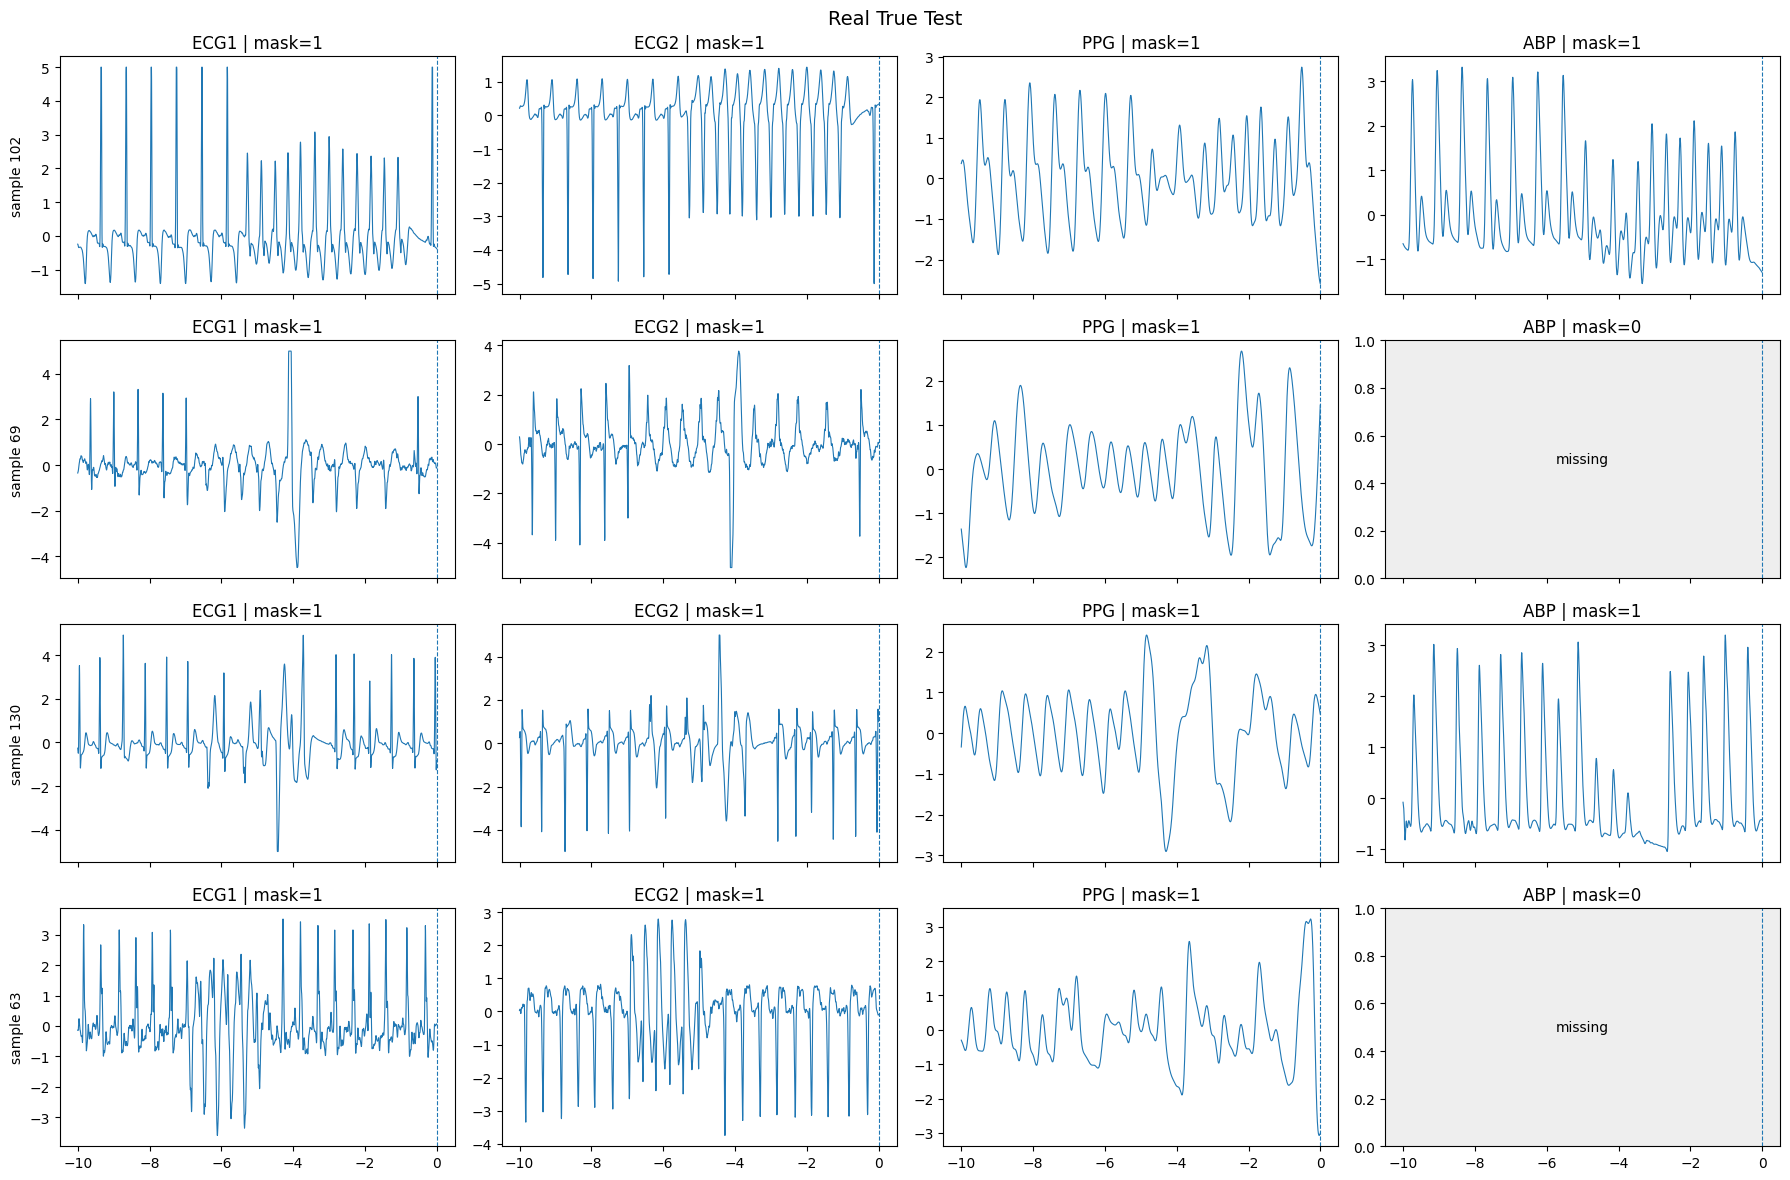

saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/waveform_examples_vanilla_cvae.png


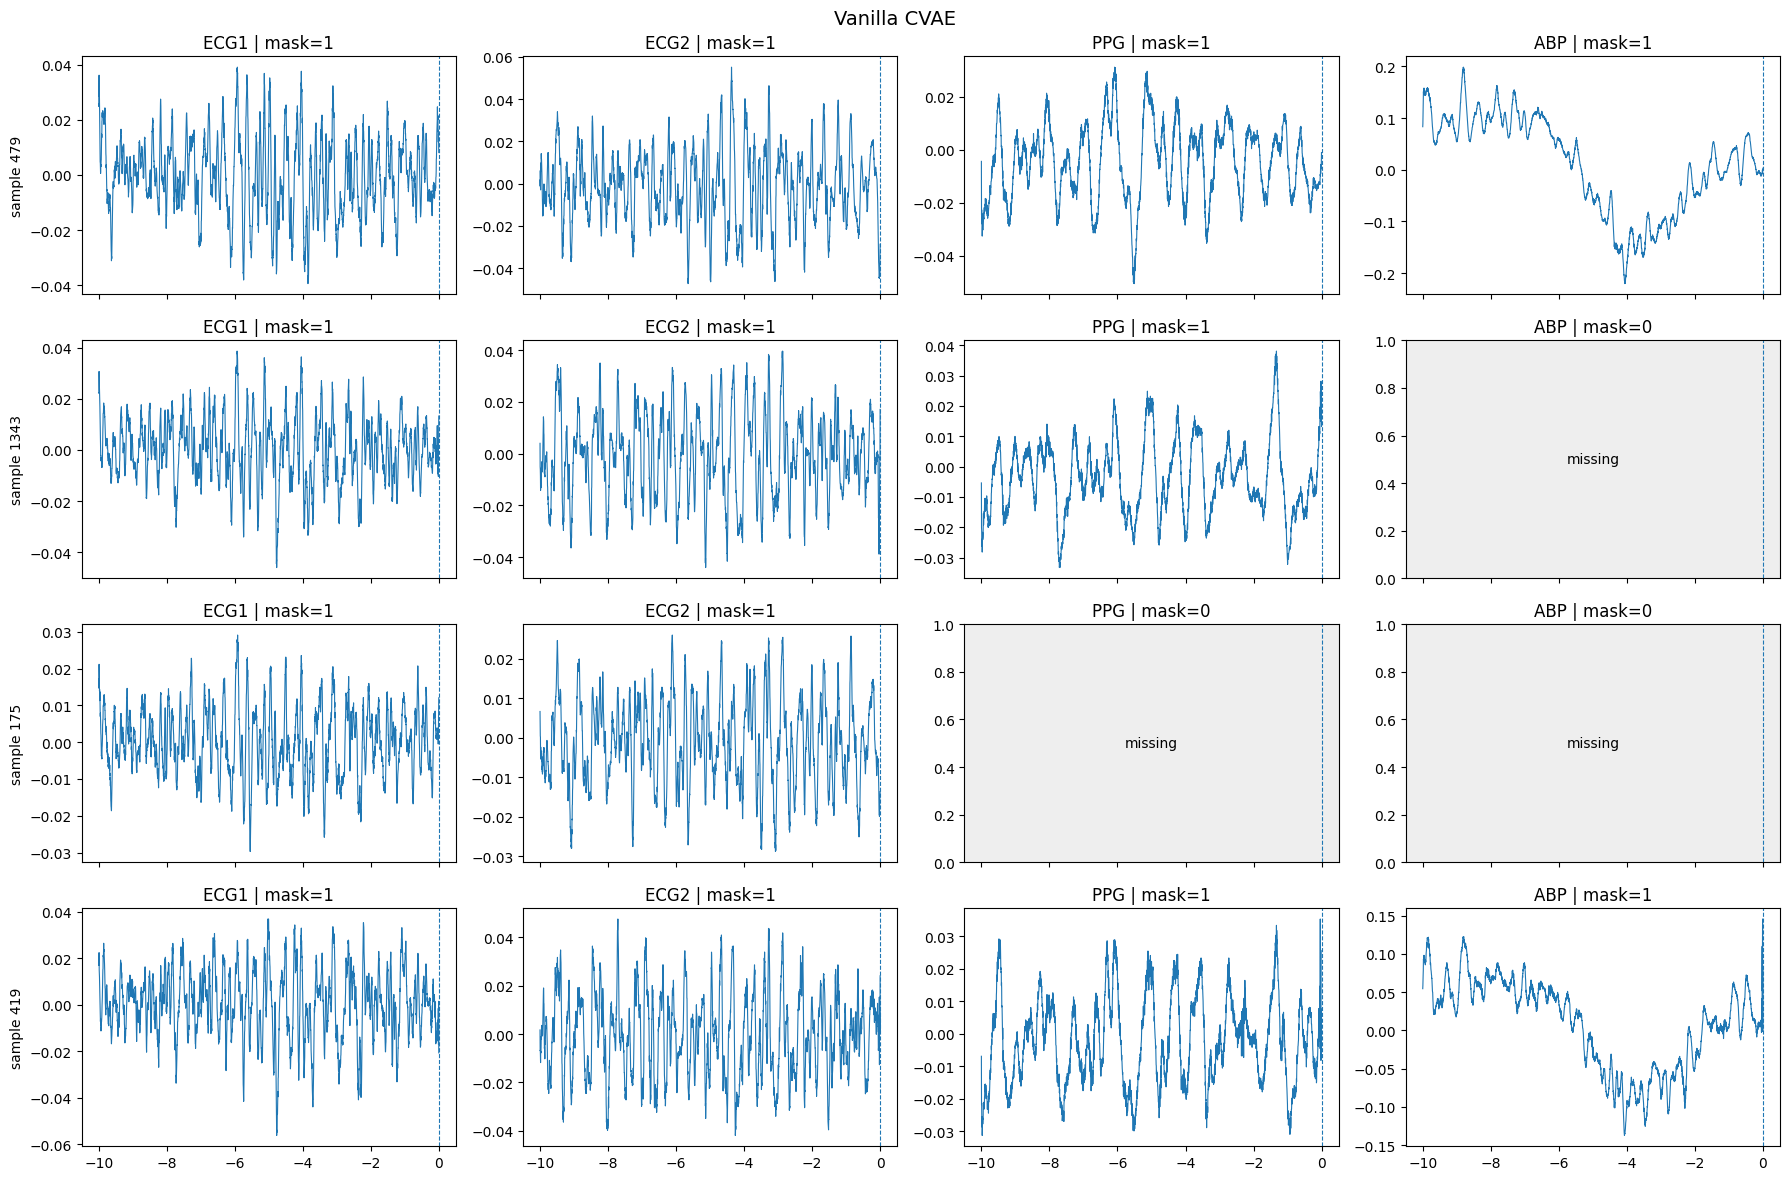

saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/waveform_examples_proposed_cvae.png


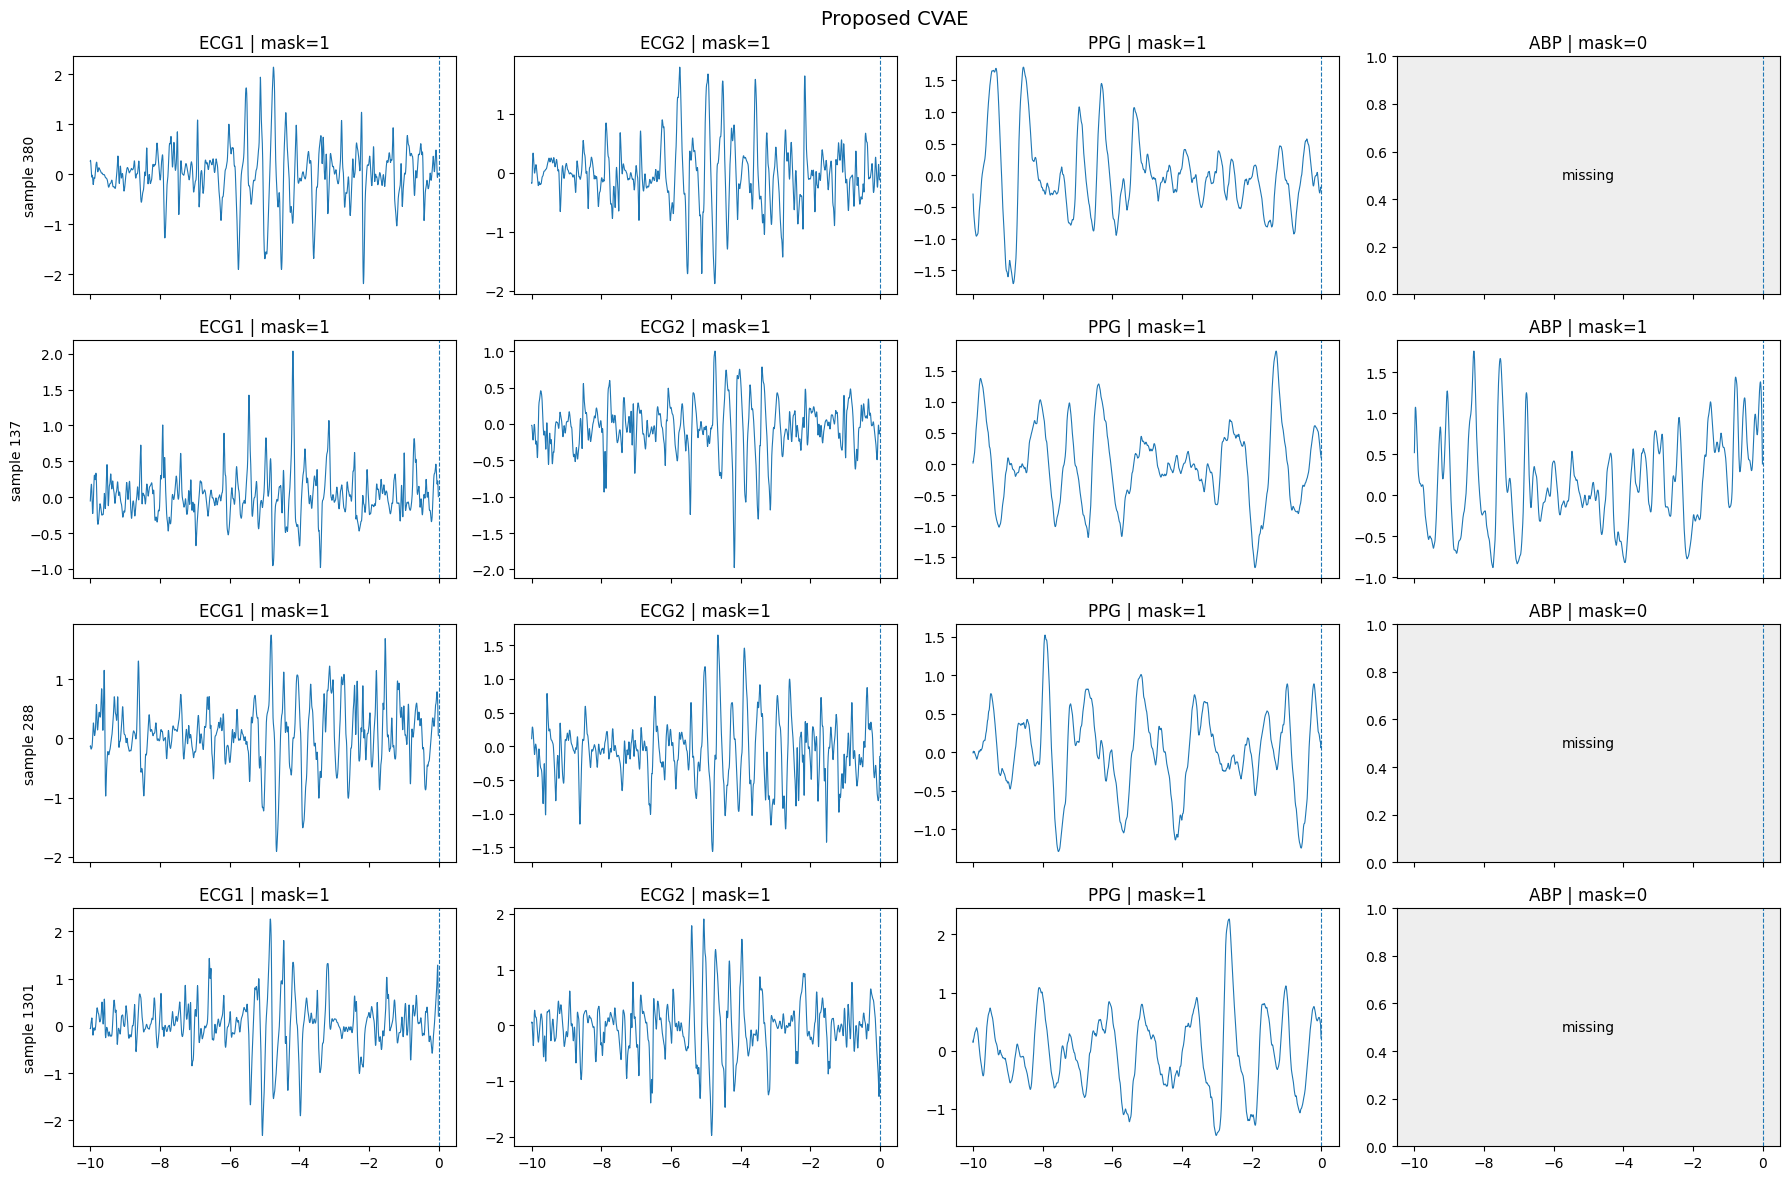

In [8]:

# ============================================================
# 3. Visual waveform inspection
# ============================================================

def choose_indices_with_signal(m, n_examples=4, seed=42):
    rng = np.random.default_rng(seed)
    valid = torch.where(m.sum(dim=1) >= 2)[0].cpu().numpy()
    if len(valid) == 0:
        valid = np.arange(len(m))
    n = min(n_examples, len(valid))
    return rng.choice(valid, size=n, replace=False)


def plot_waveform_examples(name, X, m, n_examples=4, seed=42, fs=250, save=True):
    idxs = choose_indices_with_signal(m, n_examples=n_examples, seed=seed)
    T = X.shape[-1]
    t = np.arange(T) / fs + WINDOW_SEC[0]

    fig, axes = plt.subplots(len(idxs), len(CHANNELS), figsize=(18, 3.0 * len(idxs)), sharex=True)
    if len(idxs) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, idx in enumerate(idxs):
        x = X[int(idx)].cpu().numpy()
        mask = m[int(idx)].cpu().numpy()
        for c, ch in enumerate(CHANNELS):
            ax = axes[r, c]
            if mask[c] > 0.5:
                ax.plot(t, x[c], linewidth=0.8)
            else:
                ax.text(0.5, 0.5, 'missing', ha='center', va='center', transform=ax.transAxes)
                ax.set_facecolor('#eeeeee')
            ax.axvline(0, linestyle='--', linewidth=0.8)
            ax.set_title(f'{ch} | mask={int(mask[c])}')
            if c == 0:
                ax.set_ylabel(f'sample {int(idx)}')
    fig.suptitle(name, fontsize=14)
    fig.tight_layout()

    if save:
        out = os.path.join(REALISM_OUT_DIR, f'waveform_examples_{name.lower().replace(" ", "_").replace("/", "_")}.png')
        fig.savefig(out, dpi=180, bbox_inches='tight')
        print('saved:', out)
    plt.show()

plot_waveform_examples('Real True Test', X_real_ref, m_real_ref, n_examples=4, seed=1)
plot_waveform_examples('Vanilla CVAE', X_syn_vanilla, m_syn_vanilla, n_examples=4, seed=2)
plot_waveform_examples('Proposed CVAE', X_syn_prop, m_syn_prop, n_examples=4, seed=3)



## 4. PCA / UMAP embedding

Features are built from masked multichannel waveforms using downsampled waveform values, simple channel statistics, derivative statistics, and channel masks. PCA/UMAP are used only for visualization.


saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/pca_real_vs_synthetic.png


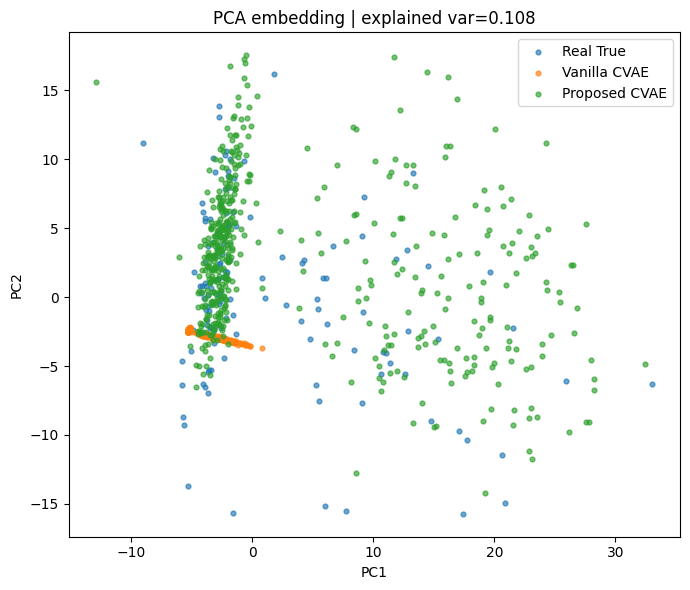

saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/umap_real_vs_synthetic.png


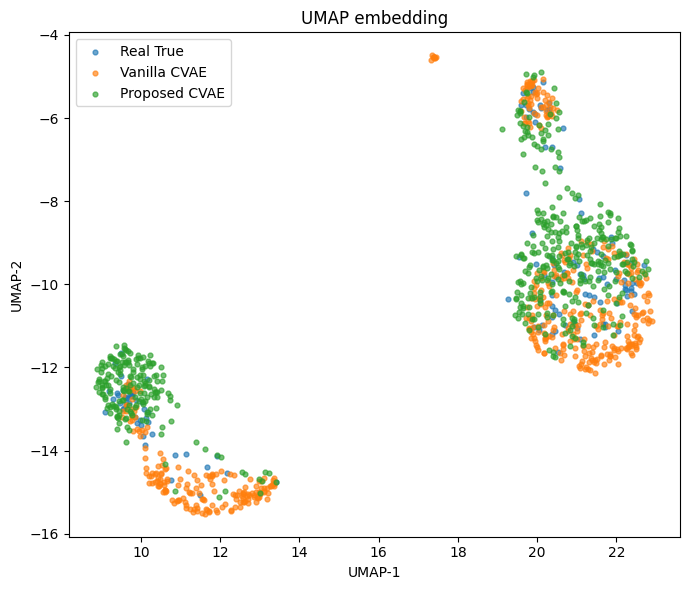

In [9]:

# ============================================================
# 4. PCA / UMAP embedding
# ============================================================

def sample_tensors(X, m, max_n=500, seed=42):
    rng = np.random.default_rng(seed)
    n = len(X)
    idx = np.arange(n)
    if n > max_n:
        idx = rng.choice(idx, size=max_n, replace=False)
    return X[idx].float(), m[idx].float(), idx


def make_realism_features(X, m, down_len=200):
    """
    X: [N, 4, T], m: [N, 4]
    returns feature matrix [N, D]
    """
    X = X.float() * m.float().unsqueeze(-1)

    # low-resolution waveform shape
    X_ds = F.adaptive_avg_pool1d(X, down_len).reshape(X.shape[0], -1)

    # basic amplitude and slope statistics per channel
    mask = m.float()
    denom = mask.unsqueeze(-1).clamp_min(1e-6)

    mean = X.mean(dim=-1)
    std = X.std(dim=-1)
    abs_mean = X.abs().mean(dim=-1)
    max_abs = X.abs().amax(dim=-1)
    q25 = torch.quantile(X, 0.25, dim=-1)
    q75 = torch.quantile(X, 0.75, dim=-1)

    dX = X[:, :, 1:] - X[:, :, :-1]
    d_std = dX.std(dim=-1)
    d_abs_mean = dX.abs().mean(dim=-1)

    stats = torch.cat([mean, std, abs_mean, max_abs, q25, q75, d_std, d_abs_mean, mask], dim=1)
    feat = torch.cat([X_ds, stats], dim=1)
    return feat.cpu().numpy()

# Use equal maximum sample count per group for fair visualization.
MAX_EMBED_N = 500
Xr_e, mr_e, _ = sample_tensors(X_real_ref, m_real_ref, max_n=MAX_EMBED_N, seed=10)
Xv_e, mv_e, _ = sample_tensors(X_syn_vanilla, m_syn_vanilla, max_n=MAX_EMBED_N, seed=11)
Xp_e, mp_e, _ = sample_tensors(X_syn_prop, m_syn_prop, max_n=MAX_EMBED_N, seed=12)

Fr = make_realism_features(Xr_e, mr_e, down_len=200)
Fv = make_realism_features(Xv_e, mv_e, down_len=200)
Fp = make_realism_features(Xp_e, mp_e, down_len=200)

features = np.vstack([Fr, Fv, Fp])
labels = np.array(['Real True'] * len(Fr) + ['Vanilla CVAE'] * len(Fv) + ['Proposed CVAE'] * len(Fp))

features_z = StandardScaler().fit_transform(features)

pca2 = PCA(n_components=2, random_state=SEED)
Z_pca = pca2.fit_transform(features_z)

embed_df = pd.DataFrame({
    'x': Z_pca[:, 0],
    'y': Z_pca[:, 1],
    'Group': labels,
    'Embedding': 'PCA',
})

plt.figure(figsize=(7, 6))
for group in ['Real True', 'Vanilla CVAE', 'Proposed CVAE']:
    sub = embed_df[embed_df['Group'] == group]
    plt.scatter(sub['x'], sub['y'], s=12, alpha=0.65, label=group)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'PCA embedding | explained var={pca2.explained_variance_ratio_.sum():.3f}')
plt.legend()
plt.tight_layout()
pca_path = os.path.join(REALISM_OUT_DIR, 'pca_real_vs_synthetic.png')
plt.savefig(pca_path, dpi=180, bbox_inches='tight')
print('saved:', pca_path)
plt.show()

# UMAP is optional. Install in Colab if unavailable.
try:
    import umap
except Exception:
    print('umap-learn not found. Installing...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'umap-learn'])
    import umap

reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.15, metric='euclidean', random_state=SEED)
Z_umap = reducer.fit_transform(features_z)

umap_df = pd.DataFrame({
    'x': Z_umap[:, 0],
    'y': Z_umap[:, 1],
    'Group': labels,
    'Embedding': 'UMAP',
})

plt.figure(figsize=(7, 6))
for group in ['Real True', 'Vanilla CVAE', 'Proposed CVAE']:
    sub = umap_df[umap_df['Group'] == group]
    plt.scatter(sub['x'], sub['y'], s=12, alpha=0.65, label=group)
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.title('UMAP embedding')
plt.legend()
plt.tight_layout()
umap_path = os.path.join(REALISM_OUT_DIR, 'umap_real_vs_synthetic.png')
plt.savefig(umap_path, dpi=180, bbox_inches='tight')
print('saved:', umap_path)
plt.show()

embed_df.to_csv(os.path.join(REALISM_OUT_DIR, 'pca_embedding_points.csv'), index=False)
umap_df.to_csv(os.path.join(REALISM_OUT_DIR, 'umap_embedding_points.csv'), index=False)



## 5. Frequency spectrum comparison

Average Welch power spectral density is compared by channel. The closer synthetic PSD is to real true-alarm PSD, the more realistic the frequency content is.


saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/frequency_spectrum_comparison.png


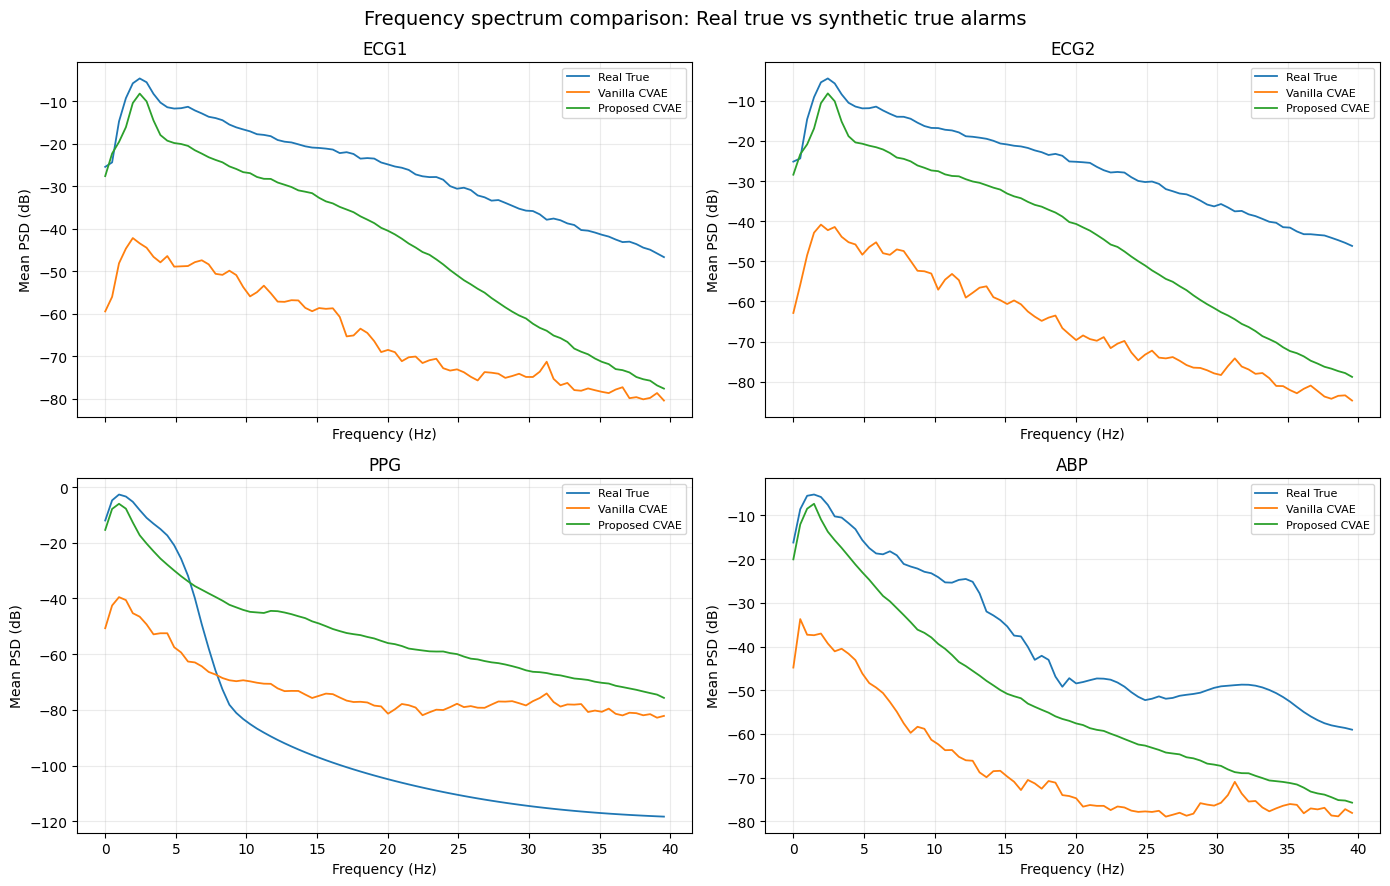

,Channel,Group,PSD_L1_logdB_to_real,N_valid
11,ABP,Proposed CVAE,13.403721,500
10,ABP,Vanilla CVAE,29.306876,500
2,ECG1,Proposed CVAE,17.205471,500
1,ECG1,Vanilla CVAE,38.477233,500
5,ECG2,Proposed CVAE,17.727616,500
4,ECG2,Vanilla CVAE,39.145108,500
7,PPG,Vanilla CVAE,29.260748,500
8,PPG,Proposed CVAE,39.117209,500


saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/frequency_spectrum_distance.csv


In [10]:

# ============================================================
# 5. Frequency spectrum comparison
# ============================================================

def mean_welch_psd(X, m, ch_idx, fs=250, max_n=500, nperseg=512, seed=42):
    valid = torch.where(m[:, ch_idx] > 0.5)[0].cpu().numpy()
    if len(valid) == 0:
        return None, None
    rng = np.random.default_rng(seed)
    if len(valid) > max_n:
        valid = rng.choice(valid, size=max_n, replace=False)

    psds = []
    freqs = None
    for idx in valid:
        x = X[int(idx), ch_idx].cpu().numpy().astype(float)
        f, pxx = welch(x, fs=fs, nperseg=min(nperseg, len(x)))
        freqs = f
        psds.append(pxx)
    return freqs, np.vstack(psds)

psd_summary_rows = []
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()

for ch_idx, ch in enumerate(CHANNELS):
    ax = axes[ch_idx]
    group_data = {
        'Real True': (X_real_ref, m_real_ref),
        'Vanilla CVAE': (X_syn_vanilla, m_syn_vanilla),
        'Proposed CVAE': (X_syn_prop, m_syn_prop),
    }

    real_f, real_psds = mean_welch_psd(X_real_ref, m_real_ref, ch_idx, fs=FS, seed=100 + ch_idx)
    if real_f is None:
        ax.set_title(f'{ch}: no real valid channel')
        continue

    real_mean = real_psds.mean(axis=0)
    freq_mask = real_f <= 40

    for group, (Xg, mg) in group_data.items():
        f, psds = mean_welch_psd(Xg, mg, ch_idx, fs=FS, seed=200 + ch_idx)
        if f is None:
            continue
        mean_psd = psds.mean(axis=0)
        ax.plot(f[f <= 40], 10 * np.log10(mean_psd[f <= 40] + 1e-12), linewidth=1.3, label=group)

        # PSD distance to real in log-domain over 0-40 Hz.
        common_mask = f <= 40
        real_interp = np.interp(f[common_mask], real_f, real_mean)
        log_dist = np.mean(np.abs(10 * np.log10(mean_psd[common_mask] + 1e-12) - 10 * np.log10(real_interp + 1e-12)))
        psd_summary_rows.append({
            'Channel': ch,
            'Group': group,
            'PSD_L1_logdB_to_real': float(log_dist),
            'N_valid': int(psds.shape[0]),
        })

    ax.set_title(ch)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Mean PSD (dB)')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle('Frequency spectrum comparison: Real true vs synthetic true alarms', fontsize=14)
fig.tight_layout()
psd_path = os.path.join(REALISM_OUT_DIR, 'frequency_spectrum_comparison.png')
fig.savefig(psd_path, dpi=180, bbox_inches='tight')
print('saved:', psd_path)
plt.show()

psd_summary_df = pd.DataFrame(psd_summary_rows)
psd_summary_df = psd_summary_df[psd_summary_df['Group'] != 'Real True'].sort_values(['Channel', 'PSD_L1_logdB_to_real'])
display(psd_summary_df)
psd_csv = os.path.join(REALISM_OUT_DIR, 'frequency_spectrum_distance.csv')
psd_summary_df.to_csv(psd_csv, index=False)
print('saved:', psd_csv)



## 6. ECG–PPG/ABP consistency

This is a proxy metric. For samples with ECG and pulse channels available, it computes the maximum absolute normalized cross-correlation between ECG and PPG/ABP over positive lags. Positive lag means the pulse waveform is delayed after ECG.


,Group,Pair,N_valid,PeakAbsCorr_mean,PeakAbsCorr_std,PeakSignedCorr_mean,LagSec_median,LagSec_IQR,PhysLagRate_0p08_0p60
0,Real True,ECG-PPG,120,0.224816,0.122349,0.001770,0.454,0.471,0.566667
1,Real True,ECG-ABP,50,0.292831,0.130352,0.041282,0.270,0.512,0.660000
2,Vanilla CVAE,ECG-PPG,500,0.149387,0.033891,-0.015485,0.436,0.613,0.432000
3,Vanilla CVAE,ECG-ABP,500,0.193958,0.028705,0.192463,0.044,0.024,0.150000
4,Proposed CVAE,ECG-PPG,500,0.171587,0.056715,0.038664,0.372,0.380,0.560000
5,Proposed CVAE,ECG-ABP,500,0.183299,0.053733,0.122072,0.228,0.614,0.316000


saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/ecg_pulse_consistency.csv
saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/ecg_pulse_PeakAbsCorr_mean.png


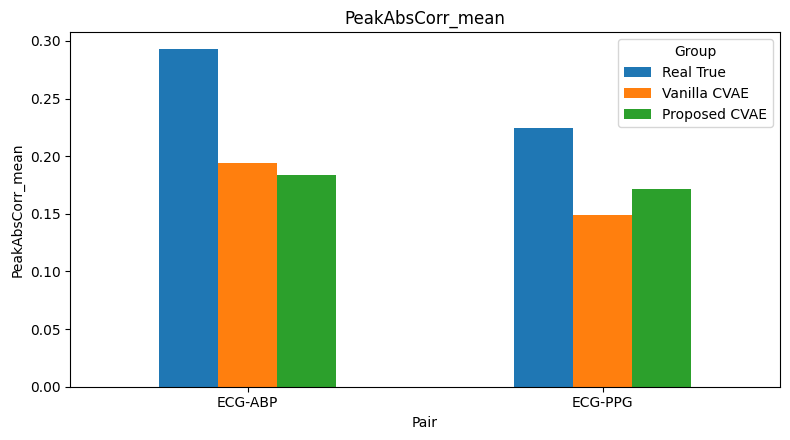

saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/ecg_pulse_LagSec_median.png


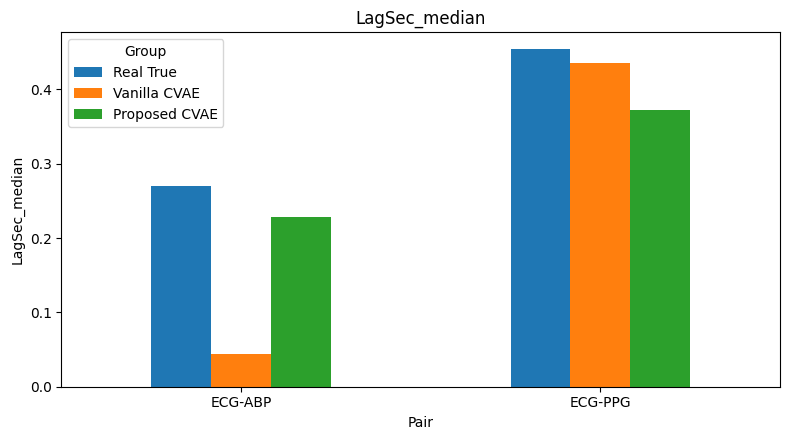

saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/ecg_pulse_PhysLagRate_0p08_0p60.png


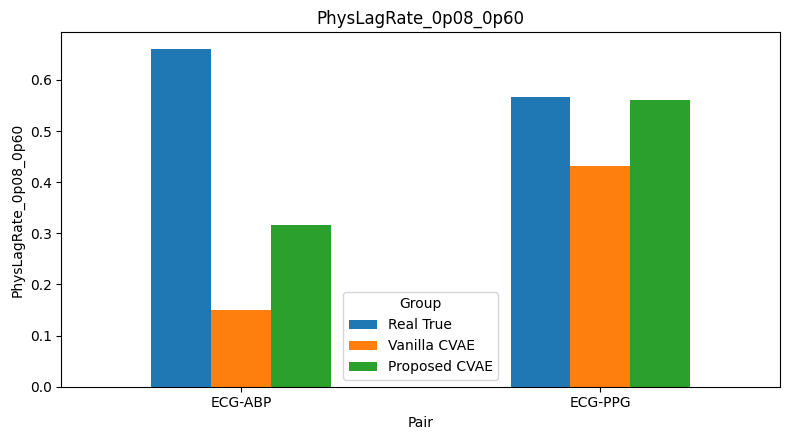

In [11]:

# ============================================================
# 6. ECG–PPG/ABP consistency
# ============================================================

def zscore_np(x):
    x = np.asarray(x, dtype=float)
    s = x.std()
    if s < 1e-8:
        return None
    return (x - x.mean()) / (s + 1e-8)


def ecg_reference_signal(x, mask):
    ecg_signals = []
    if mask[0] > 0.5:
        ecg_signals.append(x[0])
    if mask[1] > 0.5:
        ecg_signals.append(x[1])
    if len(ecg_signals) == 0:
        return None
    return np.mean(np.stack(ecg_signals, axis=0), axis=0)


def max_abs_corr_positive_lag(ecg, pulse, fs=250, min_lag_sec=0.00, max_lag_sec=1.00):
    ecg = zscore_np(ecg)
    pulse = zscore_np(pulse)
    if ecg is None or pulse is None:
        return None, None, None

    T = min(len(ecg), len(pulse))
    ecg = ecg[:T]
    pulse = pulse[:T]

    min_lag = int(round(min_lag_sec * fs))
    max_lag = int(round(max_lag_sec * fs))
    max_lag = min(max_lag, T - 2)

    corrs = []
    lags = []
    for lag in range(min_lag, max_lag + 1):
        a = ecg[:T - lag]
        b = pulse[lag:T]
        corr = float(np.mean(a * b))
        corrs.append(corr)
        lags.append(lag)

    corrs = np.asarray(corrs)
    lags = np.asarray(lags)
    if len(corrs) == 0:
        return None, None, None

    best_idx = int(np.argmax(np.abs(corrs)))
    return float(np.abs(corrs[best_idx])), float(corrs[best_idx]), float(lags[best_idx] / fs)


def compute_pulse_consistency(name, X, m, fs=250, max_n=500, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    pair_info = [('ECG-PPG', 2), ('ECG-ABP', 3)]

    for pair_name, pulse_ch in pair_info:
        # require pulse channel and at least one ECG channel
        valid = torch.where((m[:, pulse_ch] > 0.5) & ((m[:, 0] > 0.5) | (m[:, 1] > 0.5)))[0].cpu().numpy()
        if len(valid) > max_n:
            valid = rng.choice(valid, size=max_n, replace=False)

        vals_abs, vals_signed, vals_lag = [], [], []
        for idx in valid:
            x = X[int(idx)].cpu().numpy()
            mask = m[int(idx)].cpu().numpy()
            ecg = ecg_reference_signal(x, mask)
            pulse = x[pulse_ch]
            peak_abs, peak_signed, lag_sec = max_abs_corr_positive_lag(ecg, pulse, fs=fs, min_lag_sec=0.00, max_lag_sec=1.00)
            if peak_abs is None:
                continue
            vals_abs.append(peak_abs)
            vals_signed.append(peak_signed)
            vals_lag.append(lag_sec)

        vals_abs = np.asarray(vals_abs)
        vals_signed = np.asarray(vals_signed)
        vals_lag = np.asarray(vals_lag)
        phys_lag_rate = float(np.mean((vals_lag >= 0.08) & (vals_lag <= 0.60))) if len(vals_lag) else np.nan

        rows.append({
            'Group': name,
            'Pair': pair_name,
            'N_valid': int(len(vals_abs)),
            'PeakAbsCorr_mean': float(np.mean(vals_abs)) if len(vals_abs) else np.nan,
            'PeakAbsCorr_std': float(np.std(vals_abs)) if len(vals_abs) else np.nan,
            'PeakSignedCorr_mean': float(np.mean(vals_signed)) if len(vals_signed) else np.nan,
            'LagSec_median': float(np.median(vals_lag)) if len(vals_lag) else np.nan,
            'LagSec_IQR': float(np.quantile(vals_lag, 0.75) - np.quantile(vals_lag, 0.25)) if len(vals_lag) else np.nan,
            'PhysLagRate_0p08_0p60': phys_lag_rate,
        })
    return rows

consistency_rows = []
for name, Xg, mg in [
    ('Real True', X_real_ref, m_real_ref),
    ('Vanilla CVAE', X_syn_vanilla, m_syn_vanilla),
    ('Proposed CVAE', X_syn_prop, m_syn_prop),
]:
    consistency_rows.extend(compute_pulse_consistency(name, Xg, mg, fs=FS, max_n=500, seed=SEED))

consistency_df = pd.DataFrame(consistency_rows)
display(consistency_df)

consistency_csv = os.path.join(REALISM_OUT_DIR, 'ecg_pulse_consistency.csv')
consistency_df.to_csv(consistency_csv, index=False)
print('saved:', consistency_csv)

# Bar plot: peak absolute correlation and median lag.
for metric in ['PeakAbsCorr_mean', 'LagSec_median', 'PhysLagRate_0p08_0p60']:
    plt.figure(figsize=(8, 4.5))
    tmp = consistency_df.pivot(index='Pair', columns='Group', values=metric)
    tmp = tmp[['Real True', 'Vanilla CVAE', 'Proposed CVAE']]
    tmp.plot(kind='bar', ax=plt.gca())
    plt.title(metric)
    plt.ylabel(metric)
    plt.xticks(rotation=0)
    plt.tight_layout()
    out = os.path.join(REALISM_OUT_DIR, f'ecg_pulse_{metric}.png')
    plt.savefig(out, dpi=180, bbox_inches='tight')
    print('saved:', out)
    plt.show()



## 7. MMD distribution distance

MMD is computed on PCA-compressed realism features. Lower MMD means the compared group is closer to the held-out real true-alarm reference distribution. A **Real Train True vs Real Test True** value is included as calibration.


,Reference,Compared,MMD2_biased_RBF,Kernel_sigma,N_reference,N_compared
0,Real Test True,Real Train True,0.005463,18.086788,137,400
2,Real Test True,Proposed CVAE,0.105195,15.356392,137,400
1,Real Test True,Vanilla CVAE,0.756753,1.653913,137,400


saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/mmd_realism_distance.csv
saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/mmd_realism_distance.png


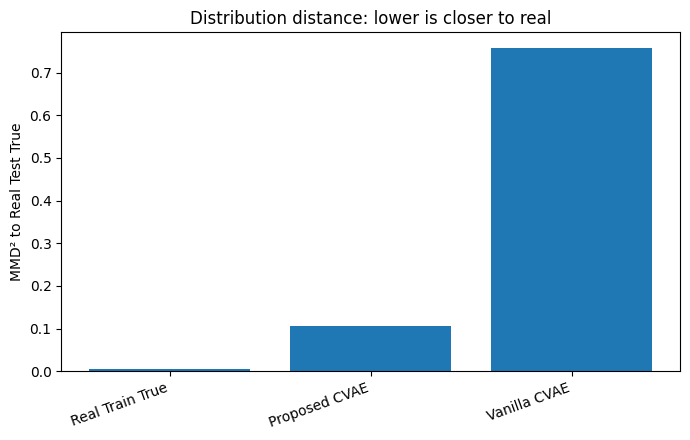

In [12]:

# ============================================================
# 7. MMD distribution distance
# ============================================================

def prepare_mmd_features(groups, max_n=400, down_len=120, pca_dim=32, seed=42):
    raw_feats = []
    names = []
    for i, (name, Xg, mg) in enumerate(groups):
        Xs, ms, _ = sample_tensors(Xg, mg, max_n=max_n, seed=seed + i)
        Fg = make_realism_features(Xs, ms, down_len=down_len)
        raw_feats.append(Fg)
        names.extend([name] * len(Fg))

    raw_all = np.vstack(raw_feats)
    raw_z = StandardScaler().fit_transform(raw_all)
    n_comp = min(pca_dim, raw_z.shape[0] - 1, raw_z.shape[1])
    Z = PCA(n_components=n_comp, random_state=seed).fit_transform(raw_z)

    out = {}
    s = 0
    for (name, Xg, mg), Fg in zip(groups, raw_feats):
        e = s + len(Fg)
        out[name] = Z[s:e]
        s = e
    return out


def median_heuristic_sigma(X, Y, max_points=600):
    Z = np.vstack([X, Y])
    if len(Z) > max_points:
        rng = np.random.default_rng(SEED)
        Z = Z[rng.choice(len(Z), size=max_points, replace=False)]
    D2 = pairwise_distances(Z, Z, metric='sqeuclidean')
    vals = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(vals[vals > 0])
    if not np.isfinite(med) or med <= 0:
        med = 1.0
    sigma = np.sqrt(0.5 * med)
    return float(sigma)


def rbf_mmd2_biased(X, Y, sigma=None):
    if sigma is None:
        sigma = median_heuristic_sigma(X, Y)
    gamma = 1.0 / (2.0 * sigma * sigma + 1e-12)
    Kxx = np.exp(-gamma * pairwise_distances(X, X, metric='sqeuclidean'))
    Kyy = np.exp(-gamma * pairwise_distances(Y, Y, metric='sqeuclidean'))
    Kxy = np.exp(-gamma * pairwise_distances(X, Y, metric='sqeuclidean'))
    mmd2 = float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())
    return max(mmd2, 0.0), sigma

mmd_groups = [
    ('Real Train True', X_real_train_true, m_real_train_true),
    ('Real Test True', X_real_ref, m_real_ref),
    ('Vanilla CVAE', X_syn_vanilla, m_syn_vanilla),
    ('Proposed CVAE', X_syn_prop, m_syn_prop),
]

Z_by_group = prepare_mmd_features(mmd_groups, max_n=400, down_len=120, pca_dim=32, seed=SEED)
ref = Z_by_group['Real Test True']

mmd_rows = []
for group in ['Real Train True', 'Vanilla CVAE', 'Proposed CVAE']:
    mmd2, sigma = rbf_mmd2_biased(ref, Z_by_group[group], sigma=None)
    mmd_rows.append({
        'Reference': 'Real Test True',
        'Compared': group,
        'MMD2_biased_RBF': mmd2,
        'Kernel_sigma': sigma,
        'N_reference': len(ref),
        'N_compared': len(Z_by_group[group]),
    })

mmd_df = pd.DataFrame(mmd_rows).sort_values('MMD2_biased_RBF')
display(mmd_df)

mmd_csv = os.path.join(REALISM_OUT_DIR, 'mmd_realism_distance.csv')
mmd_df.to_csv(mmd_csv, index=False)
print('saved:', mmd_csv)

plt.figure(figsize=(7, 4.5))
plt.bar(mmd_df['Compared'], mmd_df['MMD2_biased_RBF'])
plt.ylabel('MMD² to Real Test True')
plt.title('Distribution distance: lower is closer to real')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
mmd_path = os.path.join(REALISM_OUT_DIR, 'mmd_realism_distance.png')
plt.savefig(mmd_path, dpi=180, bbox_inches='tight')
print('saved:', mmd_path)
plt.show()



## 8. Compact realism summary for report/PPT

Use this table as the source for the realism slide. Lower is better for MMD and PSD distance. For ECG–Pulse consistency, closer to the real true-alarm value is better.


In [18]:

# ============================================================
# 8. Compact realism summary for report/PPT
# ============================================================

# PSD: average distance across channels.
psd_compact = (
    psd_summary_df
    .groupby('Group', as_index=False)['PSD_L1_logdB_to_real']
    .mean()
    .rename(columns={'PSD_L1_logdB_to_real': 'Mean PSD distance to real (dB)'})
)

# ECG-pulse: keep pair-wise values.
pulse_compact = consistency_df.copy()
pulse_compact['PeakAbsCorr_mean'] = pulse_compact['PeakAbsCorr_mean'].round(4)
pulse_compact['LagSec_median'] = pulse_compact['LagSec_median'].round(4)
pulse_compact['PhysLagRate_0p08_0p60'] = pulse_compact['PhysLagRate_0p08_0p60'].round(4)

# MMD.
mmd_compact = mmd_df.rename(columns={'Compared': 'Group', 'MMD2_biased_RBF': 'MMD2 to real'})[['Group', 'MMD2 to real']]

realism_summary = psd_compact.merge(mmd_compact, on='Group', how='outer')
realism_summary = realism_summary.sort_values('Group').reset_index(drop=True)

display(realism_summary)
print('ECG-pulse consistency:')
display(pulse_compact)

summary_csv = os.path.join(REALISM_OUT_DIR, 'realism_summary_compact.csv')
realism_summary.to_csv(summary_csv, index=False)
pulse_compact.to_csv(os.path.join(REALISM_OUT_DIR, 'realism_pulse_summary_compact.csv'), index=False)
print('saved:', summary_csv)

print('Generated figures/files are in:')
print(REALISM_OUT_DIR)
for p in sorted(glob.glob(os.path.join(REALISM_OUT_DIR, '*'))):
    print(os.path.basename(p))


,Group,Mean PSD distance to real (dB),MMD2 to real
0,Proposed CVAE,21.863504,0.105195
1,Real Train True,NaN,0.005463
2,Vanilla CVAE,34.047491,0.756753


ECG-pulse consistency:


,Group,Pair,N_valid,PeakAbsCorr_mean,PeakAbsCorr_std,PeakSignedCorr_mean,LagSec_median,LagSec_IQR,PhysLagRate_0p08_0p60
0,Real True,ECG-PPG,120,0.2248,0.122349,0.001770,0.454,0.471,0.5667
1,Real True,ECG-ABP,50,0.2928,0.130352,0.041282,0.270,0.512,0.6600
2,Vanilla CVAE,ECG-PPG,500,0.1494,0.033891,-0.015485,0.436,0.613,0.4320
3,Vanilla CVAE,ECG-ABP,500,0.1940,0.028705,0.192463,0.044,0.024,0.1500
4,Proposed CVAE,ECG-PPG,500,0.1716,0.056715,0.038664,0.372,0.380,0.5600
5,Proposed CVAE,ECG-ABP,500,0.1833,0.053733,0.122072,0.228,0.614,0.3160


saved: /content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla/realism_summary_compact.csv
Generated figures/files are in:
/content/drive/MyDrive/vtac_project/evaluation_realism_true_vanilla
ecg_pulse_LagSec_median.png
ecg_pulse_PeakAbsCorr_mean.png
ecg_pulse_PhysLagRate_0p08_0p60.png
ecg_pulse_consistency.csv
frequency_spectrum_comparison.png
frequency_spectrum_distance.csv
mmd_realism_distance.csv
mmd_realism_distance.png
pca_embedding_points.csv
pca_real_vs_synthetic.png
realism_pulse_summary_compact.csv
realism_summary_compact.csv
umap_embedding_points.csv
umap_real_vs_synthetic.png
waveform_examples_proposed_cvae.png
waveform_examples_real_true_test.png
waveform_examples_vanilla_cvae.png



## Reporting note

Recommended interpretation:

- **Visual inspection:** qualitative morphology check only; do not overclaim.
- **PCA/UMAP:** checks whether synthetic samples occupy a similar feature manifold as real true alarms.
- **Frequency spectrum:** checks whether synthetic signals preserve channel-wise spectral content.
- **ECG–PPG/ABP consistency:** proxy for cross-channel physiological synchronization. Because raw ECG and pulse waveforms have different morphology, use this as supporting evidence, not the sole realism metric.
- **MMD:** compact distribution-level distance. Lower values indicate closer synthetic distribution to held-out real true alarms.

Suggested slide wording:

> Realism was evaluated separately from downstream utility using visual inspection, feature-space embeddings, spectral comparison, ECG–pulse consistency, and MMD. This avoids assuming that better classifier performance necessarily implies physiologically realistic waveform generation.
